In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# 1. Create Synthetic "Skewed" Data (simulating House Prices)
# Exponential distribution is naturally right-skewed
np.random.seed(42)
original_data = np.random.exponential(scale=100000, size=1000) 

In [3]:
# Box-Cox requires strictly positive data (> 0)
# We add a small buffer just in case, though exponential is usually > 0
original_data = original_data + 10000 

In [4]:
# 2. Apply Box-Cox Transformation
# stats.boxcox returns two things: the transformed data and the optimal lambda found
transformed_data, best_lambda = stats.boxcox(original_data)

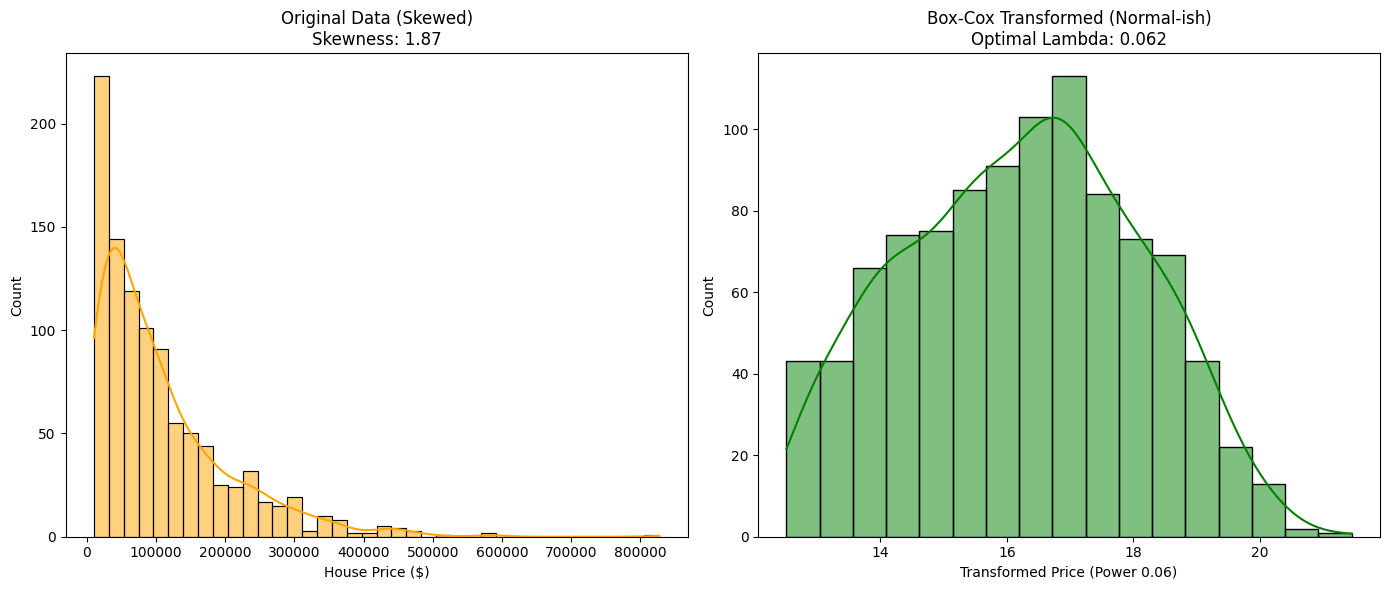

The algorithm discovered that Lambda = 0.062 is the best power to normalize this data.


In [5]:
# 3. Plotting Before vs. After
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot Original
sns.histplot(original_data, kde=True, ax=ax[0], color='orange')
ax[0].set_title(f"Original Data (Skewed)\nSkewness: {stats.skew(original_data):.2f}")
ax[0].set_xlabel("House Price ($)")

# Plot Transformed
sns.histplot(transformed_data, kde=True, ax=ax[1], color='green')
ax[1].set_title(f"Box-Cox Transformed (Normal-ish)\nOptimal Lambda: {best_lambda:.3f}")
ax[1].set_xlabel(f"Transformed Price (Power {best_lambda:.2f})")

plt.tight_layout()
plt.show()

print(f"The algorithm discovered that Lambda = {best_lambda:.3f} is the best power to normalize this data.")